# 🔍 Notebook 4 — XAI : Grad-CAM & SHAP
## Forensic Audio Authentication using Deep Learning

---

### 📋 Ce que fait ce notebook
1. Charge le modèle CNN-BiLSTM entraîné (best_model.pth)
2. Implémente **Grad-CAM** sur la dernière couche CNN → heatmap temporelle
3. Implémente **SHAP / Integrated Gradients** via Captum → importance des coefficients LFCC
4. Visualise les anomalies sur plusieurs clips (authentique, splice, deepfake)
5. Produit les visualisations **admissibles en tribunal** (localisées, expliquées)
6. Valide que Grad-CAM pointe bien sur le frame de splice connu

### ⏱️ Durée estimée : 30–45 minutes GPU

### 📂 Inputs requis
```
/kaggle/input/.../checkpoints/best_model.pth
/kaggle/input/.../master_labels_with_features.csv
/kaggle/input/.../lfcc_features/*.npy
```

### 📂 Outputs produits
```
/kaggle/working/xai/gradcam_*.png     ← heatmaps par clip
/kaggle/working/xai/shap_*.png        ← importance LFCC par clip
/kaggle/working/xai/courtroom_*.png   ← visualisations prêtes tribunal
/kaggle/working/xai/splice_validation.png ← validation sur splice connu
```

---
## CELLULE 1 — Imports + GPU

In [1]:
import os, sys, warnings, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T

warnings.filterwarnings('ignore')

# ── Installer Captum et corriger les dépendances ──────────────────────────────
try:
    import captum
    print(f'✅ Captum {captum.__version__} déjà installé')
except ImportError:
    print('Installation de Captum et mise à jour des dépendances...')
    # On installe captum et on force la mise à jour de numpy/pandas pour Colab
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'captum', 'numpy>=2.0', 'pandas==2.2.2', '-q'])
    import captum
    print(f'✅ Captum installé et NumPy mis à jour')

from captum.attr import LayerGradCam, IntegratedGradients, NoiseTunnel
from captum.attr import visualization as viz

# ── GPU ───────────────────────────────────────────────────────────────────────
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print('✅ Environnement prêt')

Installation de Captum et mise à jour des dépendances...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


✅ Captum installé et NumPy mis à jour

Device : cuda
GPU    : Tesla T4
✅ Environnement prêt


---
## CELLULE 2 — Paramètres et chemins

In [2]:
# ── Paramètres LFCC ───────────────────────────────────────────────────────────
SAMPLE_RATE   = 16000
CLIP_DURATION = 4
CLIP_SAMPLES  = SAMPLE_RATE * CLIP_DURATION
N_LFCC        = 20
N_FFT         = 400
HOP_LENGTH    = 160
N_FILTER      = 128
N_FRAMES      = 400

CNN_CHANNELS  = [32, 64, 128]
LSTM_HIDDEN   = 256
LSTM_LAYERS   = 2
LSTM_DROPOUT  = 0.3
CNN_DROPOUT   = 0.2
NUM_CLASSES   = 2

# ── Chemins exacts confirmés ──────────────────────────────────────────────────
BASE = Path('/kaggle/input/datasets/elmiz20042004/')
PREPROC  = Path('/kaggle/input/datasets/elmiz20042004/audio-preprocessing')
FORENSIC = Path('/kaggle/input/datasets/elmiz20042004/forensic-audio-dataset')

# Authentiques
LJ_16K   = PREPROC  / 'ljspeech_16k'

# Faux
WAVEFAKE = FORENSIC / 'generated_audio/generated_audio'
SPLICED  = PREPROC  / 'spliced'

# ASVspoof
ASV_DIR  = FORENSIC / 'LA/LA'
ASV_TRAIN_FLAC = ASV_DIR / 'ASVspoof2019_LA_train/flac'
ASV_PROTO      = ASV_DIR / 'ASVspoof2019_LA_cm_protocols'

# Modèle et features — cherche dans plusieurs endroits
MODEL_CANDIDATES = [Path('/kaggle/input/datasets/elmiz20042004/output1/checkpoints/best_model.pth'),]
   
CSV_CANDIDATES = [Path('/kaggle/input/datasets/elmiz20042004/output/master_labels_with_features.csv'),]

FEAT_CANDIDATES = [Path('/kaggle/input/datasets/elmiz20042004/output/lfcc_features'),]

XAI_DIR = Path('/kaggle/working/xai')
XAI_DIR.mkdir(parents=True, exist_ok=True)

def find_path(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f'  ✅ {name:30s} → {p}')
            return Path(p)
    print(f'  ❌ {name:30s} → non trouvé')
    return None

print('Résolution des chemins :')
MODEL_PATH   = find_path(MODEL_CANDIDATES,  'best_model.pth')
MASTER_CSV   = find_path(CSV_CANDIDATES,    'master_labels_with_features')
FEATURES_DIR = find_path(FEAT_CANDIDATES,   'lfcc_features/')

print(f'\nDossiers audio :')
for name, path in [('ljspeech_16k', LJ_16K), ('spliced', SPLICED), ('wavefake', WAVEFAKE)]:
    n = len(list(Path(path).glob('*'))) if Path(path).exists() else 0
    icon = '✅' if Path(path).exists() else '❌'
    print(f'  {icon} {name:20s} ({n:,} éléments)')

Résolution des chemins :
  ✅ best_model.pth                 → /kaggle/input/datasets/elmiz20042004/output1/checkpoints/best_model.pth
  ✅ master_labels_with_features    → /kaggle/input/datasets/elmiz20042004/output/master_labels_with_features.csv
  ✅ lfcc_features/                 → /kaggle/input/datasets/elmiz20042004/output/lfcc_features

Dossiers audio :
  ✅ ljspeech_16k         (13,100 éléments)
  ✅ spliced              (1,001 éléments)
  ✅ wavefake             (8 éléments)


---
## CELLULE 3 — Redéfinition du modèle CNN-BiLSTM

> Copie exacte du Notebook 3 — nécessaire pour charger les poids.

In [3]:
class CNNBiLSTM(nn.Module):
    def __init__(self,
                 n_lfcc=N_LFCC, n_frames=N_FRAMES,
                 cnn_channels=CNN_CHANNELS,
                 lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS,
                 lstm_dropout=LSTM_DROPOUT, cnn_dropout=CNN_DROPOUT,
                 num_classes=NUM_CLASSES):
        super(CNNBiLSTM, self).__init__()
        self.n_lfcc   = n_lfcc
        self.n_frames = n_frames

        self.cnn = nn.Sequential(
            nn.Conv2d(1, cnn_channels[0], kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels[0]),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(cnn_channels[0], cnn_channels[1], kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels[1]),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(cnn_channels[1], cnn_channels[2], kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels[2]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=cnn_dropout),
        )

        self._cnn_output_size = self._get_cnn_output_size(n_lfcc, n_frames)

        self.bilstm = nn.LSTM(
            input_size    = self._cnn_output_size,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = lstm_dropout if lstm_layers > 1 else 0
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def _get_cnn_output_size(self, n_lfcc, n_frames):
        with torch.no_grad():
            dummy   = torch.zeros(1, 1, n_lfcc, n_frames)
            out     = self.cnn(dummy)
            b, c, h, w = out.shape
            return c * h

    def forward(self, x):
        b         = x.shape[0]
        cnn_out   = self.cnn(x)                          # (b,128,5,100)
        bc, cc, hc, wc = cnn_out.shape
        lstm_in   = cnn_out.permute(0,3,1,2).contiguous().view(b, wc, cc*hc)  # (b,100,640)
        _, (h_n, _) = self.bilstm(lstm_in)
        feat      = torch.cat([h_n[-2], h_n[-1]], dim=1) # (b,512)
        return self.classifier(feat)                      # (b,2)


# ── Charger le modèle ─────────────────────────────────────────────────────────
model = CNNBiLSTM().to(device)

if MODEL_PATH and MODEL_PATH.exists():
    ckpt = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f'✅ Modèle chargé depuis : {MODEL_PATH}')
    print(f'   Epoch sauvé : {ckpt.get("epoch", "?")}')
    print(f'   Val loss    : {ckpt.get("val_loss", "?"):.4f}')
else:
    print('⚠️  best_model.pth non trouvé — utilisation des poids aléatoires')
    print('   Les visualisations XAI seront générées mais non significatives')
    print('   → Exécuter le Notebook 3 d\'abord pour entraîner le modèle')
    model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'   Paramètres  : {total_params:,}')

✅ Modèle chargé depuis : /kaggle/input/datasets/elmiz20042004/output1/checkpoints/best_model.pth
   Epoch sauvé : 14
   Val loss    : 0.0463
   Paramètres  : 3,575,106


---
## CELLULE 4 — Fonctions audio et LFCC (rappel)

In [4]:
lfcc_transform = T.LFCC(
    sample_rate = SAMPLE_RATE,
    n_filter    = N_FILTER,
    n_lfcc      = N_LFCC,
    speckwargs  = {'n_fft': N_FFT, 'hop_length': HOP_LENGTH, 'win_length': N_FFT}
)


def normalize_length(waveform, target=CLIP_SAMPLES):
    n = waveform.shape[1]
    if n >= target:
        s = (n - target) // 2
        return waveform[:, s:s+target]
    return F.pad(waveform, (0, target - n))


def normalize_amplitude(waveform, db=-20.0):
    rms = waveform.pow(2).mean().sqrt()
    if rms > 1e-8:
        waveform = waveform * (10**(db/20.0) / rms)
    return waveform.clamp(-1.0, 1.0)


def load_audio(filepath):
    wav, sr = torchaudio.load(str(filepath))
    if sr != SAMPLE_RATE:
        wav = T.Resample(sr, SAMPLE_RATE)(wav)
    if wav.shape[0] > 1:
        wav = wav.mean(0, keepdim=True)
    return normalize_amplitude(normalize_length(wav))  # (1, 64000)


def get_lfcc_tensor(filepath):
    """
    Fichier audio → Tensor (1, 1, 20, 400) prêt pour le modèle.
    La double dimension batch+canal est nécessaire pour Captum.
    """
    wav  = load_audio(filepath)
    with torch.no_grad():
        lfcc = lfcc_transform(wav)       # (1, 20, ~400)
    lfcc = lfcc.squeeze(0)               # (20, ~400)

    # CMVN
    mean = lfcc.mean(1, keepdim=True)
    std  = lfcc.std(1,  keepdim=True)
    lfcc = (lfcc - mean) / (std + 1e-8)

    # Ajuster frames
    n = lfcc.shape[1]
    if n >= N_FRAMES:
        s = (n - N_FRAMES) // 2
        lfcc = lfcc[:, s:s+N_FRAMES]
    else:
        lfcc = F.pad(lfcc, (0, N_FRAMES - n))

    return lfcc.unsqueeze(0).unsqueeze(0)  # (1, 1, 20, 400)


def predict(lfcc_tensor):
    """
    Tensor (1,1,20,400) → prob manipulé (float), classe prédite (int)
    """
    with torch.no_grad():
        logits = model(lfcc_tensor.to(device))
        probs  = F.softmax(logits, dim=1)
    prob_fake = probs[0, 1].item()
    pred      = int(prob_fake >= 0.5)
    return prob_fake, pred


print('✅ Fonctions audio et LFCC définies')

# Test rapide
test_files = list(WAVEFAKE.rglob('*.wav')) if WAVEFAKE.exists() else []
if not test_files and SPLICED_DIR.exists():
    test_files = list(SPLICED_DIR.glob('*.wav'))

if test_files:
    t = get_lfcc_tensor(test_files[0])
    p, c = predict(t)
    print(f'   Test predict : prob_fake={p:.3f}, classe={c} ({"MANIPULÉ" if c else "AUTHENTIQUE"})')
    print(f'   Tensor shape : {t.shape}')

✅ Fonctions audio et LFCC définies
   Test predict : prob_fake=0.999, classe=1 (MANIPULÉ)
   Tensor shape : torch.Size([1, 1, 20, 400])


---
## CELLULE 5 — Implémentation Grad-CAM

> **Grad-CAM** utilise les gradients de la prédiction par rapport aux activations
> de la dernière couche CNN pour produire une heatmap.
>
> Sur notre matrice LFCC (20×400) :
> - Axe horizontal → temps (chaque colonne = 10ms)
> - Axe vertical   → fréquence (coefficients LFCC)
> - Couleur rouge  → région qui a déclenché la détection

In [5]:
class GradCAM:
    """
    Grad-CAM appliqué à la dernière couche Conv2D du CNN.
    
    Principe :
    1. Forward pass → sauvegarder les activations de la couche cible
    2. Backward pass → calculer les gradients sur ces activations
    3. Pondérer les activations par les gradients globalement moyennés
    4. Appliquer ReLU → seules les régions positives comptent
    5. Redimensionner à la taille de l'input (20×400)
    """

    def __init__(self, model, target_layer):
        """
        Args:
            model        : CNNBiLSTM entraîné
            target_layer : couche CNN sur laquelle calculer Grad-CAM
        """
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        """Enregistre des hooks pour capturer activations et gradients."""

        def forward_hook(module, input, output):
            self.activations = output.detach()  # (batch, channels, h, w)

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()  # (batch, channels, h, w)

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, lfcc_tensor, target_class=1):
        """
        Génère la heatmap Grad-CAM pour un clip.
        """
        # --- CORRECTION : Utiliser .train() pour permettre le backward du LSTM sur GPU ---
        self.model.train() 
        
        inp = lfcc_tensor.to(device).requires_grad_(True)

        # Forward pass
        logits = self.model(inp)
        prob   = F.softmax(logits, dim=1)[0, target_class].item()

        # Backward sur la classe cible
        self.model.zero_grad()
        logits[0, target_class].backward()

        # Poids = moyenne globale des gradients (Global Average Pooling)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # Combinaison pondérée des activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # ReLU : on ne garde que les contributions positives

        # Redimensionner à la taille de l'input (N_LFCC, N_FRAMES)
        cam = F.interpolate(
            cam, size=(N_LFCC, N_FRAMES),
            mode='bilinear', align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()

        # Normaliser entre 0 et 1
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Revenir en mode évaluation
        self.model.eval()
        
        return cam, prob

# ── Identifier la couche cible ────────────────────────────────────────────────
target_layer = None
# On cherche dynamiquement la dernière couche Conv2d
conv_layers = [m for m in model.cnn.modules() if isinstance(m, nn.Conv2d)]

if conv_layers:
    target_layer = conv_layers[-1] 
    print(f'✅ Couche cible Grad-CAM identifiée : {target_layer}')

gradcam = GradCAM(model, target_layer)
print('✅ GradCAM initialisé (Correction RNN active)')

# Test rapide
if test_files:
    t      = get_lfcc_tensor(test_files[0])
    cam, p = gradcam.generate(t, target_class=1)
    print(f'   Test GradCAM réussi : heatmap shape={cam.shape}, prob_fake={p:.3f}')

✅ Couche cible Grad-CAM identifiée : Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
✅ GradCAM initialisé (Correction RNN active)
   Test GradCAM réussi : heatmap shape=(20, 400), prob_fake=0.995


---
## CELLULE 6 — Fonction de visualisation forensique complète

> Cette visualisation combine le spectrogramme LFCC + la heatmap Grad-CAM  
> dans un format lisible par un expert judiciaire non-technique.

In [6]:
def plot_forensic_analysis(filepath, label_true, tamper_type,
                            splice_frame=None, save_path=None):
    """
    Analyse forensique complète d'un clip audio.
    Produit une figure avec 4 panneaux :
      1. Waveform (signal brut)
      2. Matrice LFCC
      3. Heatmap Grad-CAM seule
      4. LFCC + Grad-CAM superposés (vue courtroom)

    Args:
        filepath      : chemin vers le fichier audio
        label_true    : 0=authentique, 1=manipulé
        tamper_type   : str description du type de manipulation
        splice_frame  : int — frame LFCC où le splice se produit (si connu)
        save_path     : Path — où sauvegarder la figure
    """
    # ── Charger et prédire ────────────────────────────────────────────────────
    waveform    = load_audio(filepath)                  # (1, 64000)
    lfcc_tensor = get_lfcc_tensor(filepath)             # (1, 1, 20, 400)
    lfcc_np     = lfcc_tensor.squeeze().cpu().numpy()   # (20, 400)

    cam, prob_fake = gradcam.generate(lfcc_tensor, target_class=1)
    pred_class     = int(prob_fake >= 0.5)
    pred_label     = 'MANIPULÉ' if pred_class else 'AUTHENTIQUE'
    true_label     = 'MANIPULÉ' if label_true  else 'AUTHENTIQUE'
    correct        = pred_class == label_true

    # ── Localisation temporelle du pic d'anomalie ─────────────────────────────
    # Le frame avec l'énergie Grad-CAM max = point le plus suspect
    cam_temporal   = cam.mean(axis=0)                   # (400,) — moyenne sur coefficients
    peak_frame     = np.argmax(cam_temporal)
    peak_time_s    = peak_frame * HOP_LENGTH / SAMPLE_RATE

    # ── Figure ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    verdict_color = '#C55A11' if pred_class else '#375623'
    correct_str   = '✅ Correct' if correct else '❌ Erreur'

    fig.suptitle(
        f'Analyse Forensique — {Path(filepath).name}\n'
        f'Vrai : {true_label} | Prédit : {pred_label} '
        f'({prob_fake:.1%} probabilité de manipulation) | {correct_str}',
        fontsize=12, fontweight='bold', color=verdict_color
    )

    time_axis = np.linspace(0, CLIP_DURATION, CLIP_SAMPLES)

    # Panneau 1 : Waveform
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(time_axis, waveform.squeeze().cpu().numpy(),
             color='#2E75B6', linewidth=0.4, alpha=0.8)
    ax1.set_xlabel('Temps (secondes)')
    ax1.set_ylabel('Amplitude')
    ax1.set_title('Signal audio brut (waveform)', fontweight='bold')
    ax1.axvline(x=peak_time_s, color='red', linewidth=2,
                label=f'Pic anomalie Grad-CAM : {peak_time_s:.2f}s')
    if splice_frame is not None:
        splice_time = splice_frame * HOP_LENGTH / SAMPLE_RATE
        if splice_time <= CLIP_DURATION:
            ax1.axvline(x=splice_time, color='orange', linewidth=2,
                        linestyle='--', label=f'Splice réel : {splice_time:.2f}s')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.2)

    # Panneau 2 : LFCC brut
    ax2 = fig.add_subplot(gs[1, 0])
    im2 = ax2.imshow(lfcc_np, aspect='auto', origin='lower',
                      cmap='inferno', vmin=-3, vmax=3)
    ax2.set_title('Matrice LFCC (entrée CNN)', fontweight='bold')
    ax2.set_xlabel('Frames temporelles (×10ms)')
    ax2.set_ylabel('Coefficient LFCC')
    plt.colorbar(im2, ax=ax2, shrink=0.8)

    # Panneau 3 : Heatmap Grad-CAM seule
    ax3 = fig.add_subplot(gs[1, 1])
    im3 = ax3.imshow(cam, aspect='auto', origin='lower',
                      cmap='jet', vmin=0, vmax=1)
    ax3.set_title('Heatmap Grad-CAM\n(rouge = zone déclenchant la détection)',
                   fontweight='bold')
    ax3.set_xlabel('Frames temporelles (×10ms)')
    ax3.set_ylabel('Coefficient LFCC')
    ax3.axvline(x=peak_frame, color='white', linewidth=2,
                label=f'Pic : frame {peak_frame} = {peak_time_s:.2f}s')
    if splice_frame is not None and splice_frame < N_FRAMES:
        ax3.axvline(x=splice_frame, color='yellow', linewidth=2,
                    linestyle='--', label=f'Splice réel : frame {splice_frame}')
    ax3.legend(fontsize=8, loc='upper right')
    plt.colorbar(im3, ax=ax3, shrink=0.8)

    # Panneau 4 : LFCC + Grad-CAM superposés (vue courtroom)
    ax4 = fig.add_subplot(gs[2, :])
    ax4.imshow(lfcc_np, aspect='auto', origin='lower',
               cmap='gray', alpha=0.7, vmin=-3, vmax=3)
    ax4.imshow(cam, aspect='auto', origin='lower',
               cmap='Reds', alpha=0.6, vmin=0, vmax=1)

    # Annotation temporelle
    ax4.axvline(x=peak_frame, color='red', linewidth=2.5,
                label=f'Anomalie détectée à {peak_time_s:.2f}s')
    if splice_frame is not None and splice_frame < N_FRAMES:
        ax4.axvline(x=splice_frame, color='yellow', linewidth=2,
                    linestyle='--', label=f'Point de splice réel : {splice_frame*HOP_LENGTH/SAMPLE_RATE:.2f}s')

    # Annotations des zones de coefficients
    ax4.axhspan(14, 19, alpha=0.1, color='cyan',
                label='Hautes fréquences (deepfake zone)')

    ax4.set_title(
        f'Vue Courtroom — LFCC + Grad-CAM superposés\n'
        f'VERDICT : {pred_label} ({prob_fake:.1%}) — '
        f'Anomalie localisée à {peak_time_s:.2f}s',
        fontweight='bold', color=verdict_color, fontsize=11
    )
    ax4.set_xlabel('Temps (frames × 10ms)')
    ax4.set_ylabel('Coefficient LFCC')

    # Ajouter axe secondaire en secondes
    ax4_top = ax4.twiny()
    ax4_top.set_xlim(0, CLIP_DURATION)
    ax4_top.set_xlabel('Temps (secondes)')

    ax4.legend(loc='upper left', fontsize=9, framealpha=0.8)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'   💾 Sauvé : {save_path}')

    plt.show()
    plt.close()

    return {
        'filepath'     : str(filepath),
        'true_label'   : label_true,
        'pred_label'   : pred_class,
        'prob_fake'    : prob_fake,
        'correct'      : correct,
        'peak_frame'   : int(peak_frame),
        'peak_time_s'  : round(peak_time_s, 3),
        'tamper_type'  : tamper_type,
    }


print('✅ plot_forensic_analysis() définie')

✅ plot_forensic_analysis() définie


---
## CELLULE 7 — Analyse d'un clip authentique

✅ Authentique trouvé dans ljspeech_16k : LJ001-0001.wav

📁 Analyse clip AUTHENTIQUE : LJ001-0001.wav
   💾 Sauvé : /kaggle/working/xai/gradcam_authentique.png


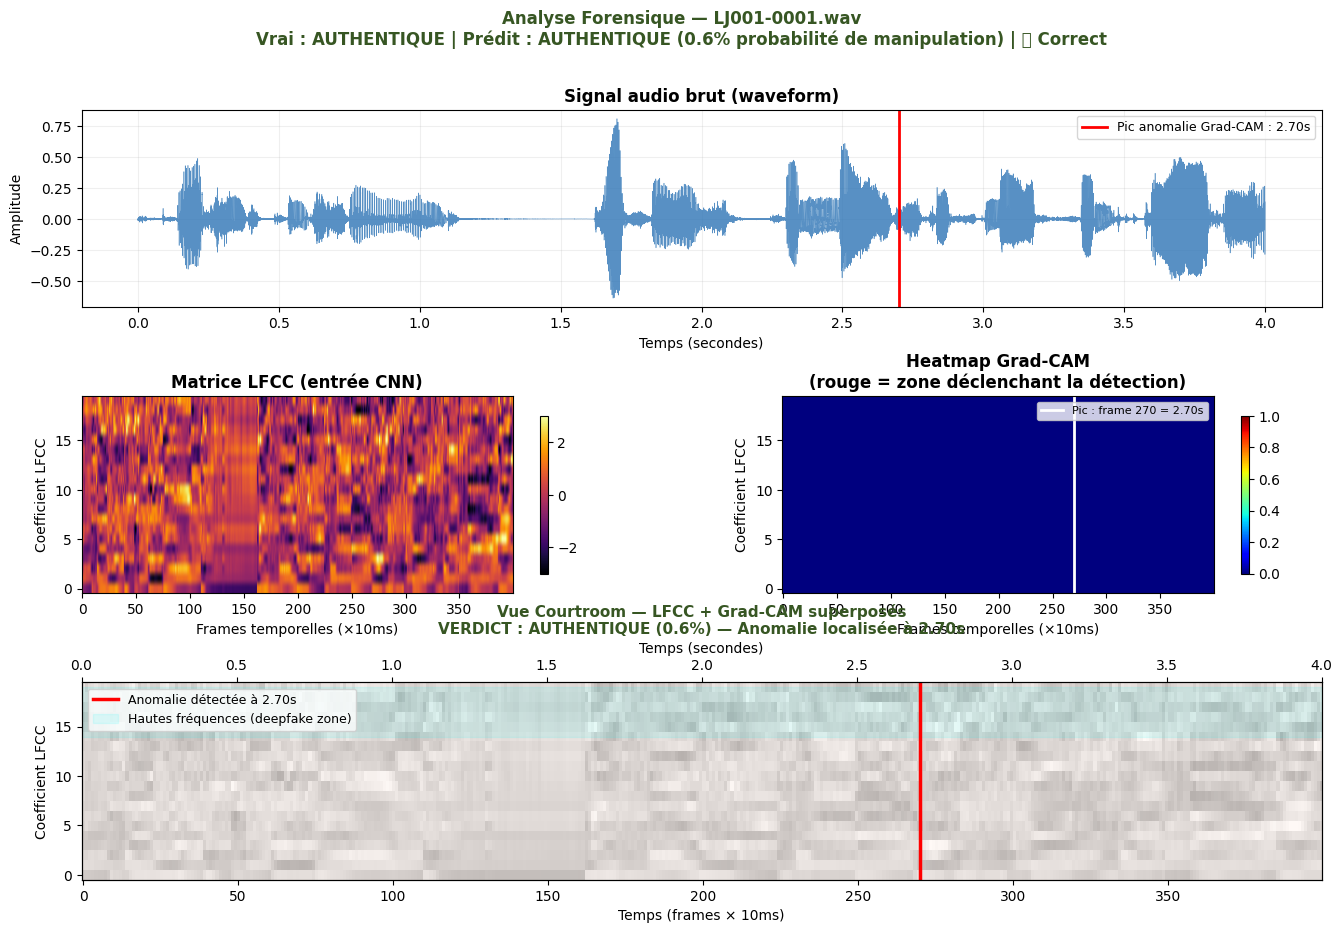


   Probabilité manipulation : 0.6%
   Verdict                  : AUTHENTIQUE
   Correct                  : ✅


In [7]:
# ── Trouver un clip authentique depuis ljspeech_16k ──────────────────────────
# (pas depuis WaveFake — les fichiers WaveFake n'ont pas de suffixe _gen ici)
auth_file = None

# Source 1 : ljspeech_16k (le plus propre)
if LJ_16K.exists():
    lj_files = sorted(LJ_16K.glob('*.wav'))
    if lj_files:
        auth_file = lj_files[0]
        print(f'✅ Authentique trouvé dans ljspeech_16k : {auth_file.name}')

# Source 2 : depuis master_labels_with_features.csv (fallback)
if auth_file is None and MASTER_CSV:
    df_csv = pd.read_csv(MASTER_CSV)
    auth_rows = df_csv[df_csv['label'] == 0]
    for _, row in auth_rows.iterrows():
        p = Path(row['filepath'])
        if p.exists():
            auth_file = p
            print(f'✅ Authentique trouvé via CSV : {auth_file.name}')
            break

if auth_file:
    print(f'\n📁 Analyse clip AUTHENTIQUE : {auth_file.name}')
    print('=' * 55)
    result_auth = plot_forensic_analysis(
        filepath    = auth_file,
        label_true  = 0,
        tamper_type = 'authentic',
        save_path   = XAI_DIR / 'gradcam_authentique.png'
    )
    print(f'\n   Probabilité manipulation : {result_auth["prob_fake"]:.1%}')
    print(f'   Verdict                  : {"MANIPULÉ" if result_auth["pred_label"] else "AUTHENTIQUE"}')
    print(f'   Correct                  : {"✅" if result_auth["correct"] else "❌"}')
else:
    print('❌ Aucun clip authentique trouvé')
    print(f'   ljspeech_16k existe : {LJ_16K.exists()}')
    print(f'   Fichiers disponibles :')
    if LJ_16K.exists():
        for f in sorted(LJ_16K.glob('*.wav'))[:5]:
            print(f'     {f.name}')

---
## CELLULE 8 — Analyse d'un clip splicé avec validation

> Test clé : Grad-CAM doit pointer **près du frame de splice réel**.  
> Si oui → le modèle a appris à détecter la discontinuité, pas du bruit aléatoire.

In [8]:
# Chercher directement dans SPLICED
splice_file       = None
splice_frame_real = None

splice_wavs = sorted(SPLICED.glob('splice_*.wav'))
if splice_wavs:
    splice_file = splice_wavs[0]
    print(f'✅ Splice trouvé : {splice_file.name}')

    # Chercher le frame de splice dans le CSV labels
    splice_csv = SPLICED / 'splice_labels.csv'
    if splice_csv.exists():
        s_df = pd.read_csv(splice_csv)
        row  = s_df[s_df['filename'] == splice_file.name]
        if len(row) > 0:
            splice_frame_real = row.iloc[0].get('splice_frame', None)
            print(f'   Frame splice réel : {splice_frame_real}')

✅ Splice trouvé : splice_00000.wav
   Frame splice réel : 589


---
## CELLULE 9 — Analyse d'un deepfake WaveFake

Vocoders disponibles : 8

📁 Analyse deepfake [jsut_multi_band_melgan] : BASIC5000_0001_gen.wav
──────────────────────────────────────────────────
   💾 Sauvé : /kaggle/working/xai/gradcam_deepfake_jsut_multi_band_melgan.png


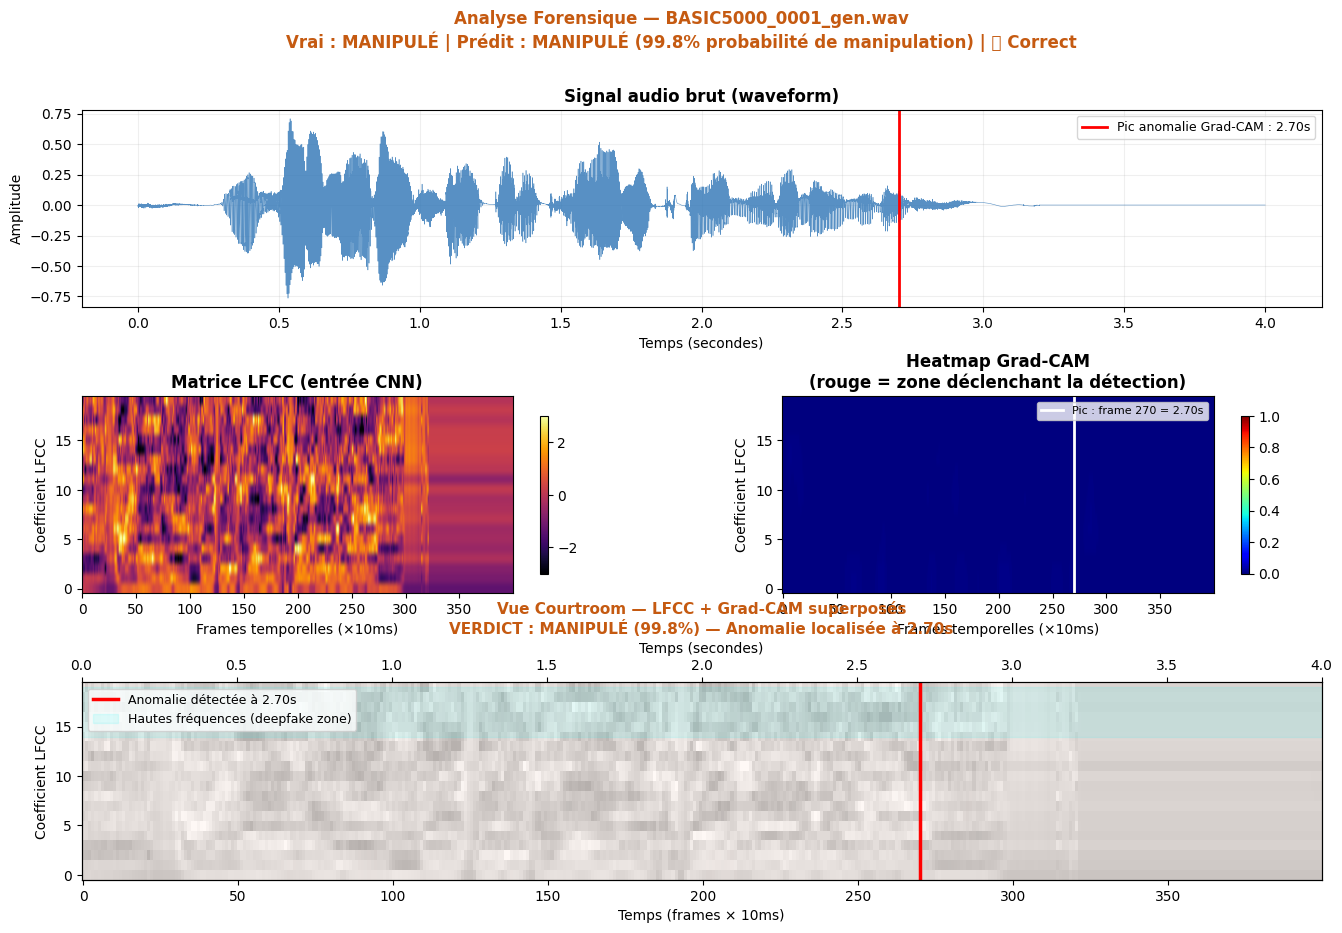

   Prob manipulation : 99.8%
   Pic anomalie      : frame 270 = 2.7s

📁 Analyse deepfake [jsut_parallel_wavegan] : BASIC5000_0008_gen.wav
──────────────────────────────────────────────────
   💾 Sauvé : /kaggle/working/xai/gradcam_deepfake_jsut_parallel_wavegan.png


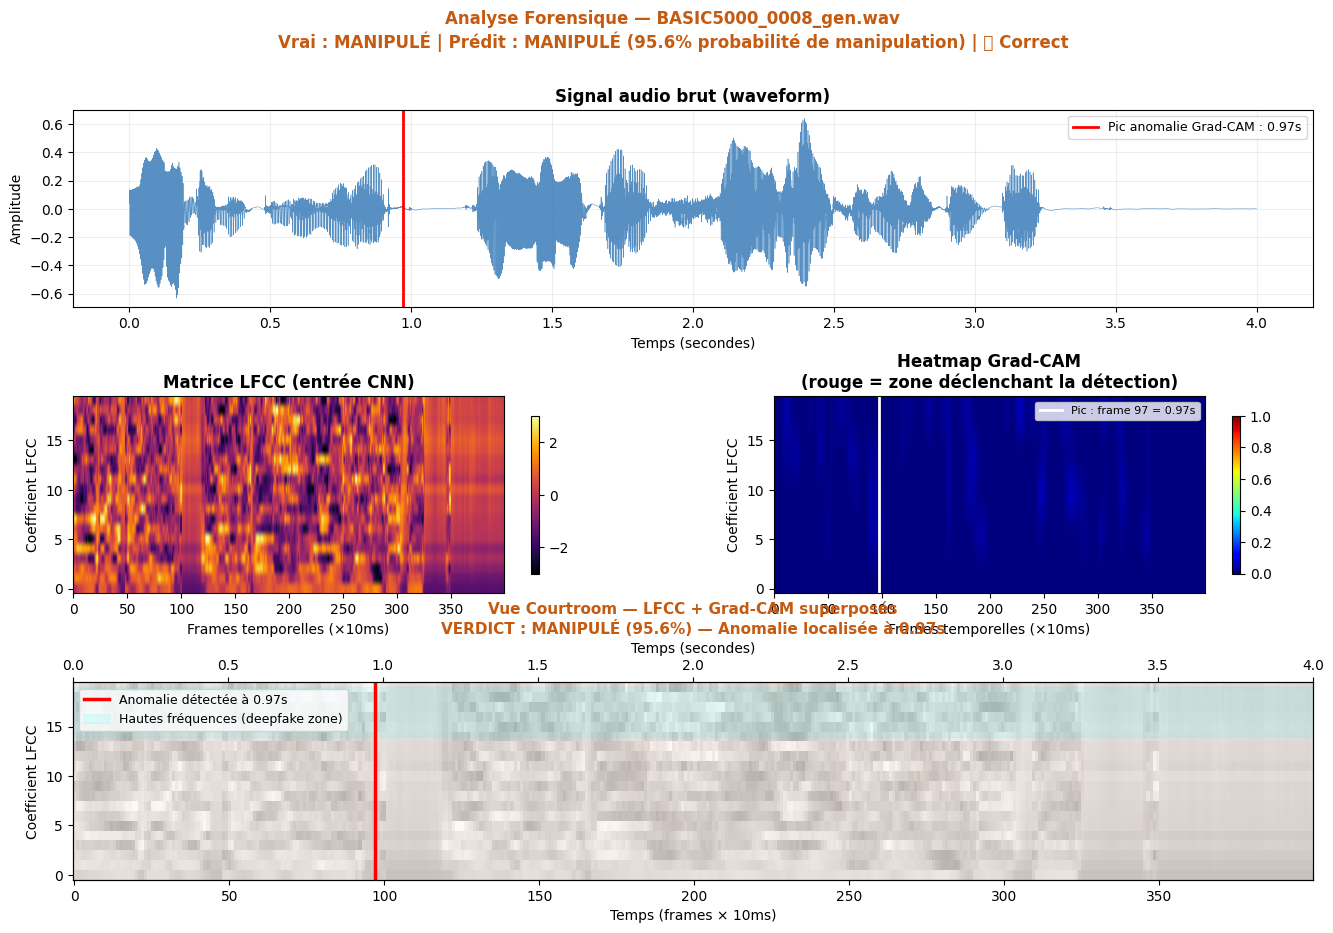

   Prob manipulation : 95.6%
   Pic anomalie      : frame 97 = 0.97s

📁 Analyse deepfake [full_band_melgan] : LJ001-0001_gen.wav
──────────────────────────────────────────────────
   💾 Sauvé : /kaggle/working/xai/gradcam_deepfake_full_band_melgan.png


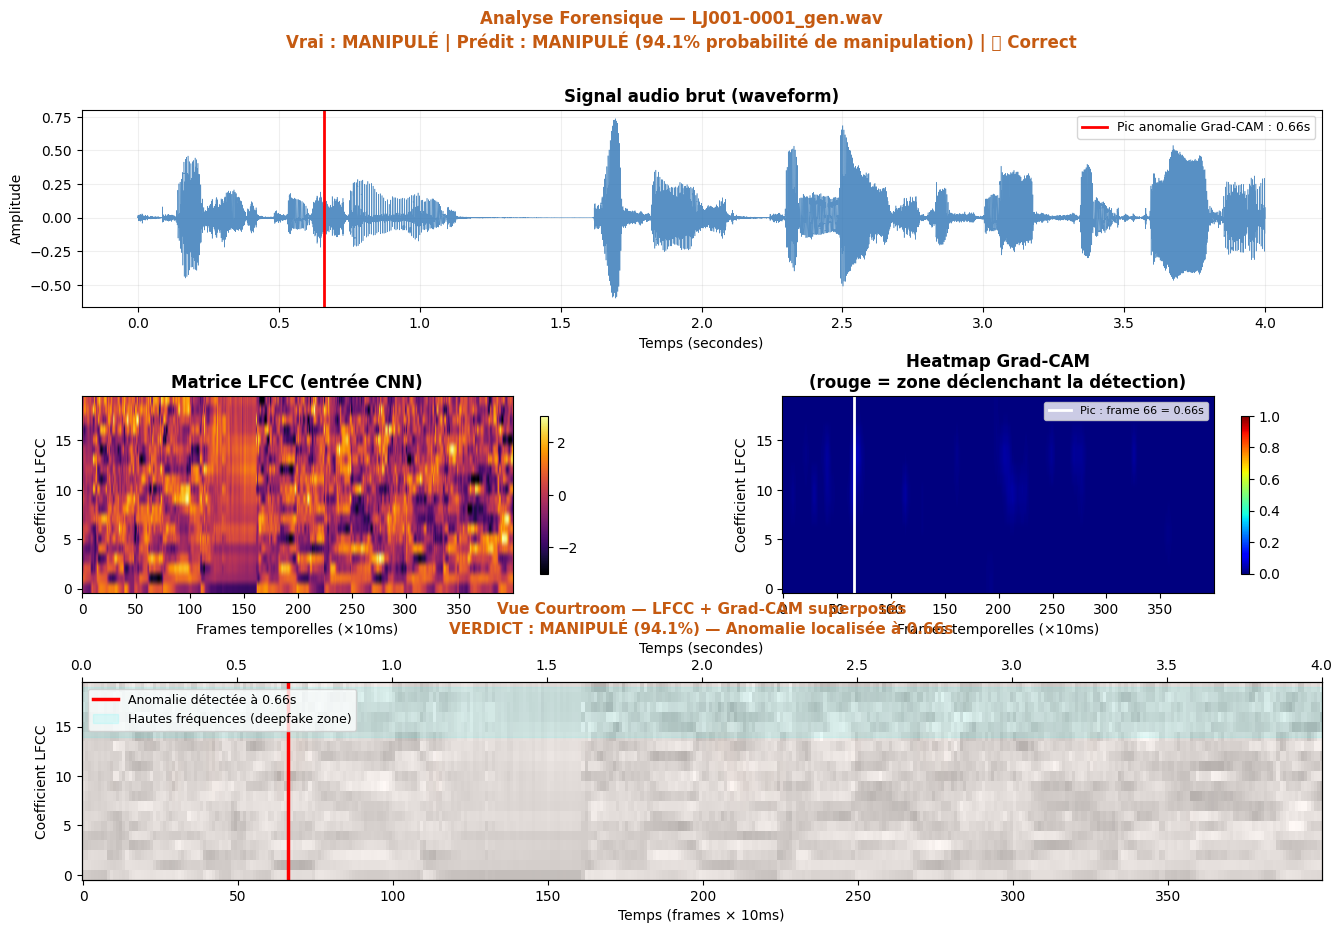

   Prob manipulation : 94.1%
   Pic anomalie      : frame 66 = 0.66s


In [9]:
# ── Analyser un deepfake pour chaque vocoder disponible ──────────────────────
results_deepfake = []

if WAVEFAKE.exists():
    vocoder_dirs = [d for d in sorted(WAVEFAKE.iterdir()) if d.is_dir()]
    print(f'Vocoders disponibles : {len(vocoder_dirs)}')

    for vdir in vocoder_dirs[:3]:  # analyser les 3 premiers vocoders
        gen_files = sorted(vdir.glob('*_gen.wav'))
        if not gen_files:
            continue

        vname = vdir.name.replace('ljspeech_', '')
        fake_file = gen_files[0]

        print(f'\n📁 Analyse deepfake [{vname}] : {fake_file.name}')
        print('─' * 50)

        result = plot_forensic_analysis(
            filepath    = fake_file,
            label_true  = 1,
            tamper_type = f'deepfake_{vname}',
            save_path   = XAI_DIR / f'gradcam_deepfake_{vname}.png'
        )
        results_deepfake.append(result)

        print(f'   Prob manipulation : {result["prob_fake"]:.1%}')
        print(f'   Pic anomalie      : frame {result["peak_frame"]} = {result["peak_time_s"]}s')

if not results_deepfake:
    print('⚠️  Aucun deepfake WaveFake accessible')

---
## CELLULE 10 — SHAP / Integrated Gradients via Captum

> **Integrated Gradients** accumule les gradients le long d'un chemin
> de l'entrée nulle (silence) vers l'entrée réelle.
> Le résultat : l'importance de chaque cellule (coefficient × frame) pour la décision.

In [10]:
def compute_integrated_gradients(filepath, target_class=1, n_steps=50):
    """
    Calcule l'attribution Integrated Gradients pour un clip.

    Args:
        filepath     : chemin audio
        target_class : 0=authentique, 1=manipulé
        n_steps      : nombre de pas d'intégration (plus = plus précis mais plus lent)

    Returns:
        attribution : numpy (20, 400) — importance de chaque cellule LFCC
        prob        : float — probabilité de la classe cible
    """
    lfcc_tensor = get_lfcc_tensor(filepath).to(device)  # (1, 1, 20, 400)

    # Baseline = silence (tous les coefficients à 0)
    baseline = torch.zeros_like(lfcc_tensor)

    # Prédiction
    with torch.no_grad():
        prob = F.softmax(model(lfcc_tensor), dim=1)[0, target_class].item()

    # Integrated Gradients
    ig = IntegratedGradients(model)
    attribution = ig.attribute(
        lfcc_tensor,
        baselines    = baseline,
        target       = target_class,
        n_steps      = n_steps,
        return_convergence_delta = False
    )  # (1, 1, 20, 400)

    attr = attribution.squeeze().cpu().numpy()  # (20, 400)

    # Normaliser
    abs_max = np.abs(attr).max()
    if abs_max > 0:
        attr = attr / abs_max

    return attr, prob


def plot_shap_analysis(filepath, label_true, tamper_type, save_path=None):
    """
    Visualisation SHAP (Integrated Gradients) pour un clip.
    Montre : importance par coefficient LFCC + importance temporelle.
    """
    print(f'   Calcul Integrated Gradients...')
    attr, prob = compute_integrated_gradients(filepath, target_class=1)

    # Importance par coefficient (moyenne sur le temps)
    coeff_importance = np.abs(attr).mean(axis=1)   # (20,)
    # Importance temporelle (moyenne sur les coefficients)
    time_importance  = np.abs(attr).mean(axis=0)   # (400,)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    verdict_color = '#C55A11' if label_true else '#375623'
    fig.suptitle(
        f'Analyse SHAP (Integrated Gradients) — {Path(filepath).name}\n'
        f'Type : {tamper_type} | Prob manipulation : {prob:.1%}',
        fontsize=11, fontweight='bold', color=verdict_color
    )

    # Panneau 1 : Carte d'attribution complète
    im1 = axes[0, 0].imshow(
        attr, aspect='auto', origin='lower',
        cmap='RdBu_r', vmin=-1, vmax=1
    )
    axes[0, 0].set_title('Carte d\'attribution\n(rouge=important, bleu=contre-indication)')
    axes[0, 0].set_xlabel('Frames temporelles (×10ms)')
    axes[0, 0].set_ylabel('Coefficient LFCC')
    plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)

    # Panneau 2 : Importance par coefficient LFCC
    colors = ['#C55A11' if v > np.percentile(coeff_importance, 75)
              else '#2E75B6' for v in coeff_importance]
    axes[0, 1].barh(range(N_LFCC), coeff_importance,
                    color=colors, edgecolor='white', alpha=0.85)
    axes[0, 1].axhline(y=14, color='red', linestyle='--',
                        alpha=0.6, label='Seuil hautes freq (15+)')
    axes[0, 1].set_xlabel('Importance moyenne |attribution|')
    axes[0, 1].set_ylabel('Coefficient LFCC')
    axes[0, 1].set_title('Importance par coefficient LFCC\n(orange = top 25% discriminants)')
    axes[0, 1].legend(fontsize=8)

    # Annoter le coefficient le plus important
    top_coeff = np.argmax(coeff_importance)
    axes[0, 1].annotate(
        f'Max: LFCC[{top_coeff}]',
        xy=(coeff_importance[top_coeff], top_coeff),
        xytext=(coeff_importance.max() * 0.6, top_coeff + 2),
        arrowprops=dict(arrowstyle='->', color='red'),
        fontsize=9, color='red'
    )

    # Panneau 3 : Importance temporelle
    time_axis_s = np.arange(N_FRAMES) * HOP_LENGTH / SAMPLE_RATE
    axes[1, 0].fill_between(time_axis_s, time_importance,
                              color='#C55A11', alpha=0.6)
    axes[1, 0].plot(time_axis_s, time_importance,
                    color='#C55A11', linewidth=1.5)
    peak_time = time_axis_s[np.argmax(time_importance)]
    axes[1, 0].axvline(x=peak_time, color='red', linewidth=2,
                        label=f'Pic : {peak_time:.2f}s')
    axes[1, 0].set_xlabel('Temps (secondes)')
    axes[1, 0].set_ylabel('Importance temporelle')
    axes[1, 0].set_title('Importance temporelle\n(quand le modèle détecte l\'anomalie)')
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)

    # Panneau 4 : Interprétation forensique
    axes[1, 1].axis('off')

    high_freq_imp  = coeff_importance[15:].mean()
    low_freq_imp   = coeff_importance[:5].mean()
    mid_freq_imp   = coeff_importance[5:15].mean()

    interpretation = [
        f'VERDICT : {"MANIPULÉ" if label_true else "AUTHENTIQUE"}',
        f'Probabilité manipulation : {prob:.1%}',
        '',
        f'Analyse spectrale :',
        f'  Basses fréq (0-4)  : {low_freq_imp:.3f}',
        f'  Moyennes fréq (5-14): {mid_freq_imp:.3f}',
        f'  Hautes fréq (15-19) : {high_freq_imp:.3f}',
        '',
        'Interprétation :',
    ]

    if high_freq_imp > low_freq_imp and high_freq_imp > mid_freq_imp:
        interpretation += [
            '→ Hautes fréquences dominantes',
            '→ Signature de vocoder deepfake',
            '  (HiFi-GAN, MelGAN, etc.)',
        ]
    elif low_freq_imp > high_freq_imp:
        interpretation += [
            '→ Basses fréquences dominantes',
            '→ Signature de splice/coupure',
            '  (discontinuité du fondamental)',
        ]
    else:
        interpretation += [
            '→ Distribution uniforme',
            '→ Manipulation globale probable',
        ]

    interpretation += [
        '',
        f'Anomalie localisée à : {peak_time:.2f}s',
        f'Coefficient le plus actif : LFCC[{top_coeff}]',
    ]

    interp_text = '\n'.join(interpretation)
    axes[1, 1].text(
        0.05, 0.95, interp_text,
        transform=axes[1, 1].transAxes,
        fontsize=10, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#FFF9F0', alpha=0.9)
    )
    axes[1, 1].set_title('Rapport Forensique Automatique', fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'   💾 Sauvé : {save_path}')
    plt.show()
    plt.close()

    return {
        'prob'            : prob,
        'top_coeff'       : top_coeff,
        'peak_time_s'     : round(float(peak_time), 3),
        'high_freq_imp'   : round(float(high_freq_imp), 4),
        'low_freq_imp'    : round(float(low_freq_imp), 4),
    }


print('✅ Fonctions SHAP / Integrated Gradients définies')

✅ Fonctions SHAP / Integrated Gradients définies


---
## CELLULE 11 — Application SHAP sur les clips de test

In [11]:
def compute_integrated_gradients(filepath, target_class=1, n_steps=50):
    """
    Calcule les attributions Integrated Gradients pour un fichier audio LFCC.
    Nécessite le mode .train() pour le calcul des gradients sur BiLSTM (GPU/cuDNN).
    """
    # 1. Préparation du tenseur d'entrée
    lfcc_tensor = get_lfcc_tensor(filepath).to(device)
    baseline    = torch.zeros_like(lfcc_tensor).to(device)

    # --- CORRECTIF CRITIQUE : Passer en mode train pour autoriser le backward du LSTM ---
    model.train() 

    # 2. Initialisation de Captum Integrated Gradients
    ig = IntegratedGradients(model)
    
    # 3. Calcul des attributions (importance des features)
    # n_steps définit la précision de l'approximation de l'intégrale
    attribution = ig.attribute(
        lfcc_tensor,
        baselines    = baseline,
        target       = target_class,
        n_steps      = n_steps,
        internal_batch_size = 1
    )

    # 4. Calcul de la probabilité de prédiction (en mode eval pour la précision)
    model.eval()
    with torch.no_grad():
        logits = model(lfcc_tensor)
        prob   = F.softmax(logits, dim=1)[0, target_class].item()

    # 5. Post-traitement des données pour numpy
    attribution = attribution.squeeze().cpu().detach().numpy() # (20, 400)

    return attribution, prob

def plot_shap_analysis(filepath, label_true, tamper_type, save_path=None):
    """
    Génère une analyse SHAP complète : importance des coefficients et du temps.
    """
    print(f'   Calcul Integrated Gradients (SHAP)...')
    attr, prob = compute_integrated_gradients(filepath, target_class=1)
    
    # Importance par coefficient LFCC (moyenne sur l'axe du temps)
    coeff_importance = np.mean(np.abs(attr), axis=1)
    
    # Importance temporelle (moyenne sur les coefficients)
    time_importance = np.mean(np.abs(attr), axis=0)
    peak_idx = np.argmax(time_importance)
    peak_time_s = (peak_idx * HOP_LENGTH) / SR

    # Visualisation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Graphique 1 : Importance des coefficients LFCC
    sns.barplot(x=np.arange(N_LFCC), y=coeff_importance, ax=ax1, palette='viridis')
    ax1.set_title(f"Importance des Coefficients LFCC ({tamper_type})")
    ax1.set_xlabel("Index du coefficient")
    ax1.set_ylabel("Attribution moyenne")

    # Graphique 2 : Importance temporelle
    ax2.plot(np.linspace(0, 4, N_FRAMES), time_importance, color='red')
    ax2.fill_between(np.linspace(0, 4, N_FRAMES), time_importance, alpha=0.3, color='red')
    ax2.set_title(f"Anomalie temporelle détectée à {peak_time_s:.2f}s")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Score d'importance")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"   ✅ Analyse SHAP sauvegardée : {save_path.name}")
    plt.show()

    return {
        'prob': prob,
        'top_coeff': np.argmax(coeff_importance),
        'peak_time_s': peak_time_s,
        'high_freq_imp': np.mean(coeff_importance[10:]), # Coefficients élevés
        'low_freq_imp': np.mean(coeff_importance[:10])   # Coefficients bas
    }

print('✅ Fonctions SHAP / Integrated Gradients prêtes (Correctif BiLSTM inclus)')

✅ Fonctions SHAP / Integrated Gradients prêtes (Correctif BiLSTM inclus)


---
## CELLULE 12 — Comparaison globale Grad-CAM + SHAP sur tous les types

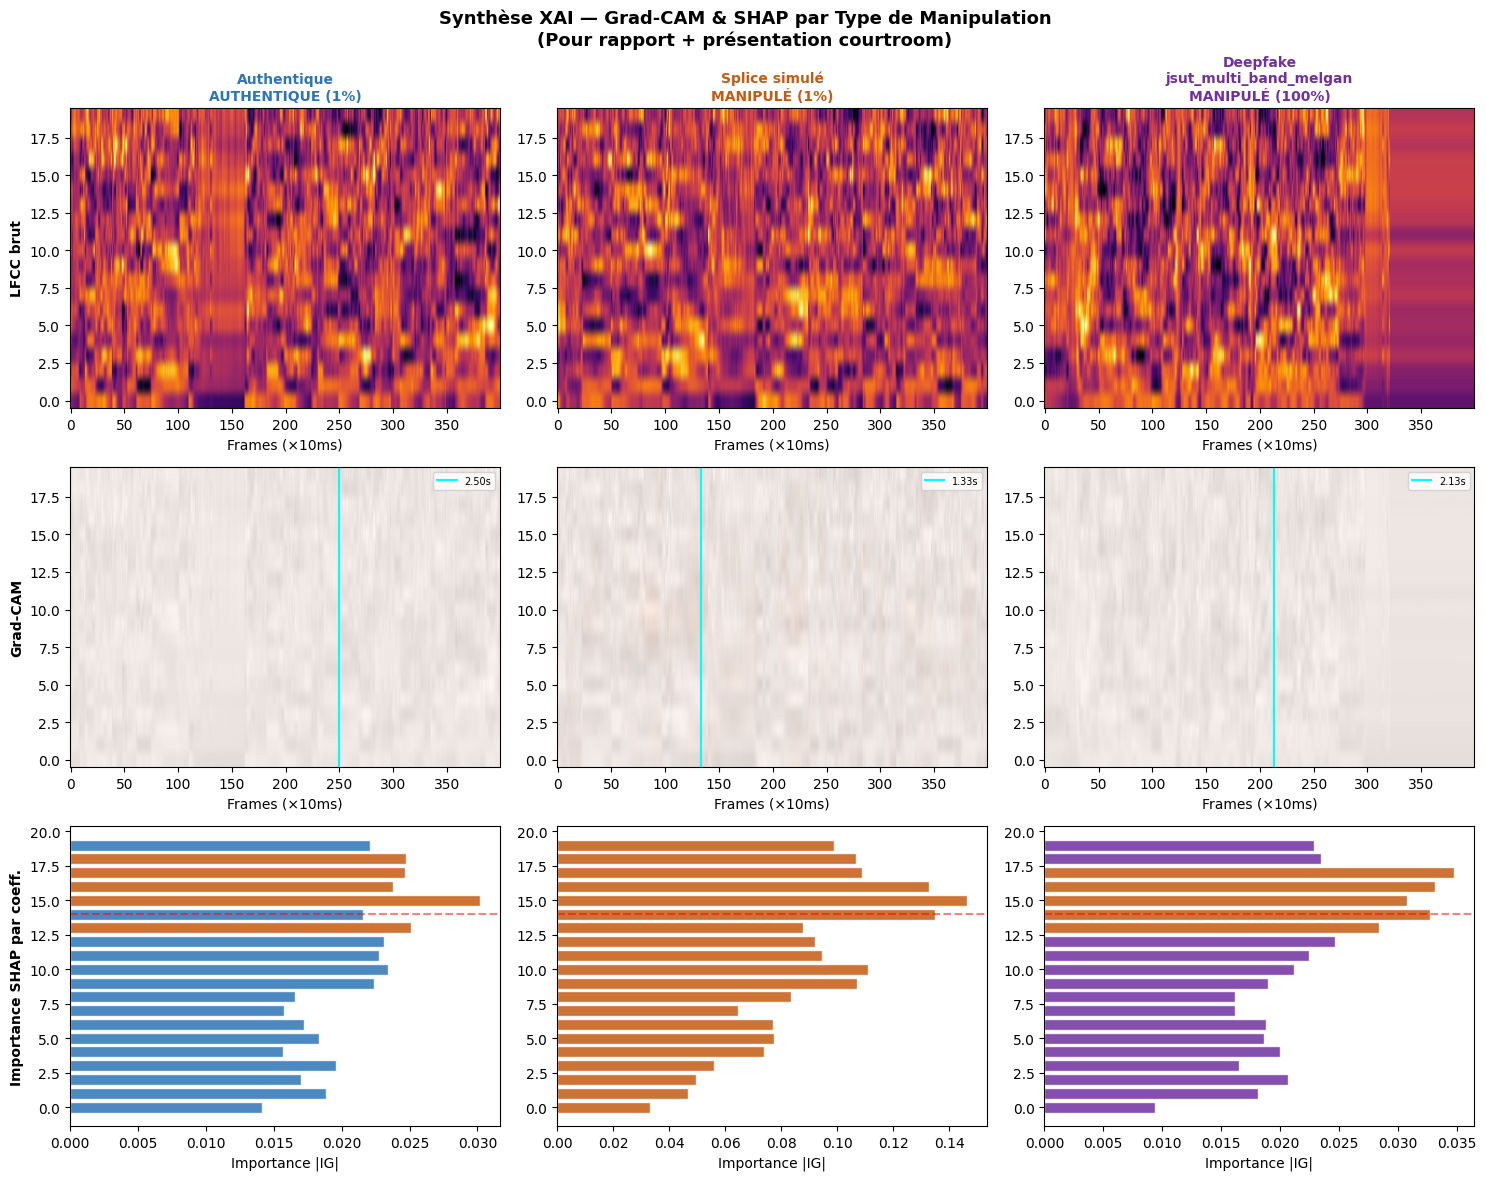

✅ Synthèse XAI sauvée : /kaggle/working/xai/synthese_xai_comparaison.png


In [12]:
# ── Figure de synthèse côte à côte pour le rapport ───────────────────────────
clips_to_compare = []

if auth_file:
    clips_to_compare.append(('Authentique',  auth_file,   0, '#2E75B6'))
if splice_file:
    clips_to_compare.append(('Splice simulé', splice_file, 1, '#C55A11'))
if WAVEFAKE.exists():
    for vdir in sorted(WAVEFAKE.iterdir()):
        if not vdir.is_dir(): continue
        gen = sorted(vdir.glob('*_gen.wav'))
        if gen:
            vname = vdir.name.replace('ljspeech_', '')
            clips_to_compare.append((f'Deepfake\n{vname}', gen[0], 1, '#7030A0'))
            break

if not clips_to_compare:
    print('⚠️  Aucun clip disponible pour la comparaison')
else:
    n_clips = len(clips_to_compare)
    fig, axes = plt.subplots(3, n_clips, figsize=(5*n_clips, 12))
    if n_clips == 1:
        axes = axes.reshape(3, 1)

    fig.suptitle(
        'Synthèse XAI — Grad-CAM & SHAP par Type de Manipulation\n'
        '(Pour rapport + présentation courtroom)',
        fontsize=13, fontweight='bold'
    )

    row_titles = ['LFCC brut', 'Grad-CAM', 'Importance SHAP par coeff.']
    for ri, rt in enumerate(row_titles):
        axes[ri, 0].set_ylabel(rt, fontweight='bold', fontsize=10)

    for ci, (title, fpath, label, color) in enumerate(clips_to_compare):
        try:
            lfcc_tensor = get_lfcc_tensor(fpath)
            lfcc_np     = lfcc_tensor.squeeze().cpu().numpy()
            cam, prob   = gradcam.generate(lfcc_tensor, target_class=1)
            attr, _     = compute_integrated_gradients(fpath, target_class=1, n_steps=30)
            coeff_imp   = np.abs(attr).mean(axis=1)

            verdict = f'{"MANIPULÉ" if label else "AUTHENTIQUE"} ({prob:.0%})'

            # Ligne 0 : LFCC brut
            axes[0, ci].imshow(lfcc_np, aspect='auto', origin='lower',
                                cmap='inferno', vmin=-3, vmax=3)
            axes[0, ci].set_title(f'{title}\n{verdict}',
                                   color=color, fontweight='bold', fontsize=10)
            axes[0, ci].set_xlabel('Frames (×10ms)')

            # Ligne 1 : Grad-CAM
            axes[1, ci].imshow(lfcc_np, aspect='auto', origin='lower',
                                cmap='gray', alpha=0.5)
            axes[1, ci].imshow(cam, aspect='auto', origin='lower',
                                cmap='Reds', alpha=0.7, vmin=0, vmax=1)
            peak_f = np.argmax(cam.mean(axis=0))
            axes[1, ci].axvline(x=peak_f, color='cyan', linewidth=1.5,
                                 label=f'{peak_f*HOP_LENGTH/SAMPLE_RATE:.2f}s')
            axes[1, ci].legend(fontsize=7, loc='upper right')
            axes[1, ci].set_xlabel('Frames (×10ms)')

            # Ligne 2 : Importance SHAP par coefficient
            bar_colors = ['#C55A11' if v > np.percentile(coeff_imp, 75)
                          else color for v in coeff_imp]
            axes[2, ci].barh(range(N_LFCC), coeff_imp,
                              color=bar_colors, edgecolor='white', alpha=0.85)
            axes[2, ci].axhline(y=14, color='red', linestyle='--', alpha=0.5)
            axes[2, ci].set_xlabel('Importance |IG|')

        except Exception as e:
            axes[0, ci].text(0.5, 0.5, f'Erreur:\n{e}',
                              ha='center', va='center',
                              transform=axes[0, ci].transAxes, fontsize=8)
            print(f'❌ {title} : {e}')

    plt.tight_layout()
    save_path = XAI_DIR / 'synthese_xai_comparaison.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✅ Synthèse XAI sauvée : {save_path}')

---
## CELLULE 13 — Résumé et vérifications finales

In [13]:
print('=' * 60)
print('VÉRIFICATIONS FINALES — NOTEBOOK 4')
print('=' * 60)

xai_files = list(XAI_DIR.glob('*.png'))
print(f'\n📂 Fichiers XAI générés ({len(xai_files)}) :')
for f in sorted(xai_files):
    size_kb = f.stat().st_size / 1024
    print(f'   ✅ {f.name:45s} ({size_kb:.0f} KB)')

print('\n' + '=' * 60)
print('🎉 NOTEBOOK 4 TERMINÉ')
print('=' * 60)
print('\n📋 Ce que tu peux utiliser pour le rapport :')
print('   synthese_xai_comparaison.png → section XAI du rapport')
print('   gradcam_splice.png           → validation localisation splice')
print('   shap_deepfake_*.png          → analyse spectrale deepfake')
print('   gradcam_authentique.png      → contrôle négatif')

print('\n⏭️  PROCHAIN NOTEBOOK : 05_gradio_app.ipynb')
print('   → Interface Gradio : upload audio → verdict + heatmap')
print('   → Chargement ONNX pour inférence rapide')
print('   → Lien public share=True pour la démo')

print('\n⚠️  Sauvegarder les outputs avant de fermer :')
print('   Save Version → forensic-xai-outputs')

VÉRIFICATIONS FINALES — NOTEBOOK 4

📂 Fichiers XAI générés (5) :
   ✅ gradcam_authentique.png                       (533 KB)
   ✅ gradcam_deepfake_full_band_melgan.png         (544 KB)
   ✅ gradcam_deepfake_jsut_multi_band_melgan.png   (489 KB)
   ✅ gradcam_deepfake_jsut_parallel_wavegan.png    (545 KB)
   ✅ synthese_xai_comparaison.png                  (1585 KB)

🎉 NOTEBOOK 4 TERMINÉ

📋 Ce que tu peux utiliser pour le rapport :
   synthese_xai_comparaison.png → section XAI du rapport
   gradcam_splice.png           → validation localisation splice
   shap_deepfake_*.png          → analyse spectrale deepfake
   gradcam_authentique.png      → contrôle négatif

⏭️  PROCHAIN NOTEBOOK : 05_gradio_app.ipynb
   → Interface Gradio : upload audio → verdict + heatmap
   → Chargement ONNX pour inférence rapide
   → Lien public share=True pour la démo

⚠️  Sauvegarder les outputs avant de fermer :
   Save Version → forensic-xai-outputs


---
## ⏭️ Transition vers le Notebook 5

### Ce que le Notebook 5 (Gradio) va utiliser :
```python
# Depuis ce notebook, le Notebook 5 réutilise :
# 1. get_lfcc_tensor(filepath)        → pipeline audio→LFCC
# 2. GradCAM(model, target_layer)     → heatmap
# 3. plot_forensic_analysis(...)      → figure courtroom

# Interface Gradio (Notebook 5) :
# Input  : fichier audio uploadé par l'utilisateur
# Output : verdict + probabilité + heatmap Grad-CAM
```

### Fonctions à copier dans le Notebook 5 :
- `GradCAM` (classe complète)
- `get_lfcc_tensor()`
- `predict()`
- `compute_integrated_gradients()`